# DCMS Tutorial — Maximum-Entropy Solvers for Directed Networks

This notebook walks through the three maximum-entropy models implemented in the `dcms` package:

| Model | Constraints | Unknowns |
|-------|-------------|----------|
| **DCM** | out-degree, in-degree | 2N log-multipliers |
| **DWCM** | out-strength, in-strength | 2N log-multipliers |
| **DaECM** | all four | 4N log-multipliers (two-step) |

For each model we show:
1. The physics: which probability distribution is being maximised
2. The self-consistency equations that must be solved
3. How the two solvers work (FP-GS and θ-Newton, both with Anderson(10))
4. How to call the code and interpret the results
5. Performance tips for large networks

**Prerequisites:** `torch`, `numpy`, `matplotlib`

In [1]:
import sys, os
# Make sure the package root is on the path
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['figure.dpi'] = 120
mpl.rcParams['font.size'] = 11

from src.utils.wng import k_s_generator_pl

print('Imports OK')

Imports OK


---
## 1. Background — Maximum-Entropy Exponential Random Graphs

### 1.1 The maximum-entropy principle

Given a set of observed network properties $\mathbf{C}^* = (C_1^*, \ldots, C_K^*)$ (e.g. the degree sequence), the maximum-entropy (MaxEnt) principle asks: *what is the least biased probability distribution over all directed graphs $G$ that reproduces these observations in expectation?*

The answer is always an **exponential family**:

$$
P(G | \boldsymbol{\theta}) = \frac{1}{Z(\boldsymbol{\theta})} \exp\!\left(-\sum_{k} \theta_k C_k(G)\right)
$$

where $\boldsymbol{\theta}$ are the Lagrange multipliers and $Z$ is the partition function.  The multipliers are found by solving the self-consistency equations $\langle C_k \rangle = C_k^*$.

### 1.2 Directed networks and link independence

For all three models in this package, the MaxEnt distribution factorises over directed links $(i \to j)$:

$$
P(G) = \prod_{i \neq j} p_{ij}^{A_{ij}} (1 - p_{ij})^{1 - A_{ij}} \quad \text{(binary case)}
$$

This means each link exists **independently** with probability $p_{ij}$, and the $p_{ij}$ are determined by the Lagrange multipliers.

### 1.3 Parametrisation

All multipliers are stored in **log-space**: $\theta_i = -\log(x_i)$, i.e. $x_i = e^{-\theta_i}$.
Working in $\theta$-space guarantees positivity of $x_i$ without box constraints and gives a better-conditioned optimisation landscape.

---
## 2. The DCM — Directed Configuration Model

### 2.1 Equations

The DCM enforces the **out-degree** $k^{\text{out}}_i$ and **in-degree** $k^{\text{in}}_i$ of every node.  The link probability is:

$$
p_{ij} = \frac{x_i y_j}{1 + x_i y_j}, \qquad x_i = e^{-\theta^{\text{out}}_i}, \quad y_j = e^{-\theta^{\text{in}}_j}
$$

and the self-consistency equations are:

$$
k^{\text{out}}_i = \sum_{j \neq i} p_{ij}, \qquad
k^{\text{in}}_i = \sum_{j \neq i} p_{ji}
$$

This is a $2N \times 2N$ nonlinear system in the unknowns $(\theta^{\text{out}}_1, \ldots, \theta^{\text{out}}_N, \theta^{\text{in}}_1, \ldots, \theta^{\text{in}}_N)$.

### 2.2 Generate a test network and build the model

In [2]:
from src.models.dcm import DCMModel

# Generate a small power-law directed network (N=50)
N = 50
k, s = k_s_generator_pl(N, rho=0.1, seed=42)
k_out = k[:N].numpy().astype(float)
k_in  = k[N:].numpy().astype(float)

model = DCMModel(k_out, k_in)

print(f'N = {N}')
print(f'k_out: min={k_out.min():.0f}  max={k_out.max():.0f}  mean={k_out.mean():.1f}')
print(f'k_in : min={k_in.min():.0f}   max={k_in.max():.0f}  mean={k_in.mean():.1f}')

N = 50
k_out: min=1  max=17  mean=5.3
k_in : min=2   max=16  mean=5.3


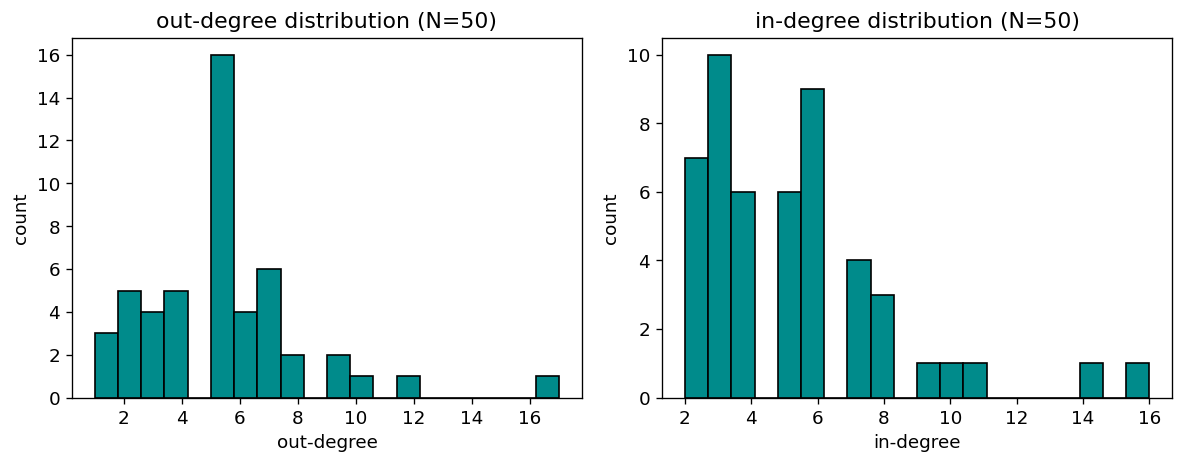

In [3]:
# Visualise the degree distribution
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, seq, label in zip(axes, [k_out, k_in], ['out-degree', 'in-degree']):
    ax.hist(seq, bins=20, color='darkcyan', edgecolor='black')
    ax.set_xlabel(label); ax.set_ylabel('count')
    ax.set_title(f'{label} distribution (N={N})')
plt.tight_layout()
plt.show()

### 2.3 Solve with FP-GS Anderson(10)

In [4]:
model.solve_tool(variant='gauss-seidel', tol=1e-8)

Converged in 15 iteration(s).


True

In [5]:
print(f'FP-GS Anderson(10):  converged={model.converged}')
print(f'  iterations  = {model.iterations}')
print(f'  max err     = {model.constraint_error(model.theta):.2e}')
print(f'  time (s)    = {model.elapsed_time:.3f}')

FP-GS Anderson(10):  converged=True
  iterations  = 15
  max err     = 2.69e-09
  time (s)    = 0.067


In [6]:
result_fpgs_residuals=model.residuals.copy()

### 2.4 Solve with θ-Newton Anderson(10)

In [7]:
model.solve_tool(variant='theta-newton', tol=1e-8)

print(f'θ-Newton Anderson(10):  converged={model.converged}')
print(f'  iterations  = {model.iterations}')
print(f'  max err     = {model.constraint_error(model.theta):.2e}')
print(f'  time (s)    = {model.elapsed_time:.3f}')

Converged in 13 iteration(s).
θ-Newton Anderson(10):  converged=True
  iterations  = 13
  max err     = 8.84e-09
  time (s)    = 0.023


In [8]:
result_tn_residuals=model.residuals.copy()

### 2.5 Convergence curves

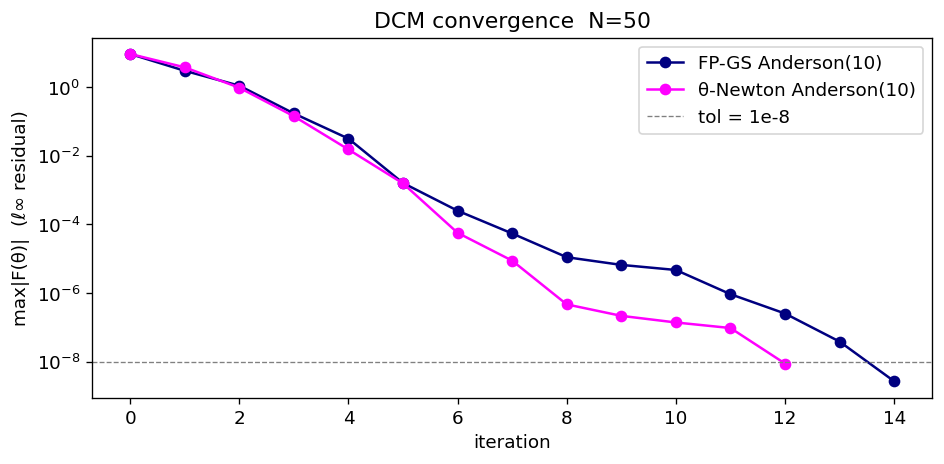

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogy(result_fpgs_residuals, label='FP-GS Anderson(10)', color='navy', marker='o')
ax.semilogy(result_tn_residuals,   label='θ-Newton Anderson(10)', color='magenta', marker='o')
ax.axhline(1e-8, color='grey', linestyle='--', linewidth=0.8, label='tol = 1e-8')

ax.set_xlabel('iteration'); ax.set_ylabel('max|F(θ)|  (ℓ∞ residual)')
ax.set_title(f'DCM convergence  N={N}')
ax.legend()
plt.tight_layout()
plt.show()

### 2.6 Inspect the solution

The recovered multipliers should reproduce the observed degrees.

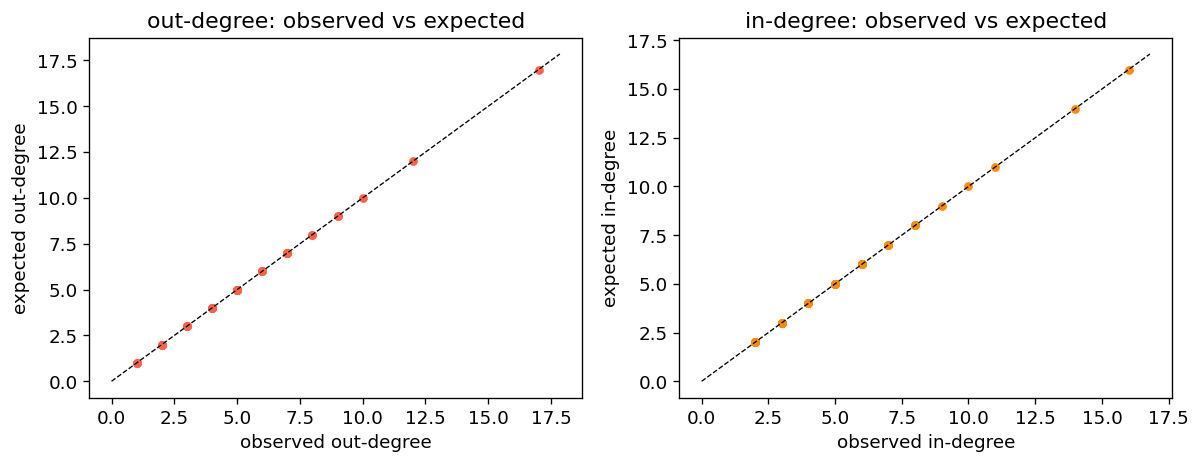

Max |Δk_out| = 8.84e-09
Max |Δk_in|  = 5.26e-09


In [10]:
theta_sol = model.theta
x = np.exp(-theta_sol[:N])
y = np.exp(-theta_sol[N:])

# Reconstruct expected degrees from the solution
xy = x[:, None] * y[None, :]
P = xy / (1 + xy)
np.fill_diagonal(P, 0.0)

k_out_hat = P.sum(axis=1)
k_in_hat  = P.sum(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, obs, rec, label, color in zip(
    axes,
    [k_out, k_in],
    [k_out_hat, k_in_hat],
    ['out-degree', 'in-degree'],
    ['tomato', 'darkorange'],
):
    lim = max(obs.max(), rec.max()) * 1.05
    ax.plot([0, lim], [0, lim], 'k--', linewidth=0.8)
    ax.scatter(obs, rec, s=18, color=color)
    ax.set_xlabel(f'observed {label}'); ax.set_ylabel(f'expected {label}')
    ax.set_title(f'{label}: observed vs expected')

plt.tight_layout()
plt.show()

print(f'Max |Δk_out| = {np.abs(k_out - k_out_hat).max():.2e}')
print(f'Max |Δk_in|  = {np.abs(k_in  - k_in_hat ).max():.2e}')

---
## 3. The DWCM — Directed Weighted Configuration Model

### 3.1 Equations

The DWCM enforces **out-strength** $s^{\text{out}}_i$ and **in-strength** $s^{\text{in}}_i$.  Weights are geometrically distributed (integer-valued), giving:

$$
\langle w_{ij} \rangle = \frac{\beta_i \beta_j}{1 - \beta_i \beta_j}, \qquad \beta_i = e^{-\theta^{\text{out}}_i}, \quad \beta_j = e^{-\theta^{\text{in}}_j}
$$

The self-consistency equations are:

$$
s^{\text{out}}_i = \sum_{j \neq i} \frac{\beta^{\text{out}}_i \beta^{\text{in}}_j}{1 - \beta^{\text{out}}_i \beta^{\text{in}}_j},
\qquad
s^{\text{in}}_i = \sum_{j \neq i} \frac{\beta^{\text{out}}_j \beta^{\text{in}}_i}{1 - \beta^{\text{out}}_j \beta^{\text{in}}_i}
$$

**Feasibility constraint:** $\beta^{\text{out}}_i \beta^{\text{in}}_j < 1$ for all $i \neq j$  (i.e. $\theta^{\text{out}}_i + \theta^{\text{in}}_j > 0$ for all pairs).

### 3.2 Why is DWCM harder than DCM?

The key difference is the **geometric-distribution correction factor** $G_{ij} = 1/(1 - \beta_i \beta_j)$.  As $\beta_i \beta_j \to 1$ (high-strength hub nodes), $G_{ij} \to \infty$ and the Jacobian of the self-consistency map becomes large.  The spectral radius of the fixed-point map exceeds 1 for hub nodes, causing plain FP to diverge.

The θ-Newton approach avoids this: the diagonal Hessian element
$$
\frac{\partial F_i}{\partial \theta_i} = -\sum_{j \neq i} G_{ij}(G_{ij} - 1)
$$
is always negative, giving a descent direction regardless of how large $G_{ij}$ is.

In [11]:
from src.models.dwcm import DWCMModel
from src.solvers.fixed_point_dwcm import solve_fixed_point_dwcm

# Use the strength sequences from the same network
s_out = s[:N].numpy().astype(float)
s_in  = s[N:].numpy().astype(float)

# Zero-out nodes with zero strength (not meaningful)
mask_out = s_out > 0
mask_in  = s_in  > 0
print(f'Nodes with s_out > 0: {mask_out.sum()} / {N}')
print(f'Nodes with s_in  > 0: {mask_in.sum()}  / {N}')
print(f's_out: min={s_out[mask_out].min():.0f}  max={s_out.max():.0f}  mean={s_out[mask_out].mean():.1f}')

Nodes with s_out > 0: 50 / 50
Nodes with s_in  > 0: 50  / 50
s_out: min=2  max=41  mean=12.2


In [20]:
model_w = DWCMModel(s_out, s_in)

In [21]:
model_w.solve_tool(tol=1e-8, variant='gauss-seidel')

print(f'FP-GS Anderson(10):  converged={model_w.converged}')
print(f'  iterations  = {model_w.iterations}')
print(f'  max err     = {model_w.constraint_error(model_w.theta):.2e}')
print(f'  time (s)    = {model_w.elapsed_time:.3f}')

Converged in 20 iteration(s).
FP-GS Anderson(10):  converged=True
  iterations  = 20
  max err     = 5.57e-10
  time (s)    = 0.176


In [22]:
result_fpgs_residuals=model_w.residuals.copy()

In [25]:
model_w.solve_tool(tol=1e-8, variant='theta-newton')
print(f'θ-Newton Anderson(10):  converged={model_w.converged}')
print(f'  iterations  = {model_w.iterations}')
print(f'  max err     = {model_w.constraint_error(model_w.theta):.2e}')
print(f'  time (s)    = {model_w.elapsed_time:.3f}')


Converged in 14 iteration(s).
θ-Newton Anderson(10):  converged=True
  iterations  = 14
  max err     = 1.47e-09
  time (s)    = 0.029


In [26]:
result_tn_residuals=model_w.residuals.copy()

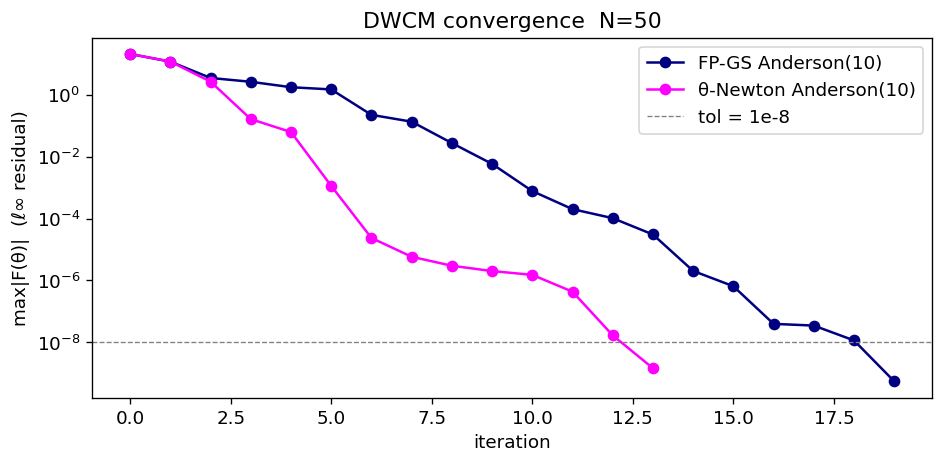

In [28]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.semilogy(result_fpgs_residuals, label='FP-GS Anderson(10)', color='navy', marker='o')
ax.semilogy(result_tn_residuals,   label='θ-Newton Anderson(10)', color='magenta', marker='o')
ax.axhline(1e-8, color='grey', linestyle='--', linewidth=0.8, label='tol = 1e-8')

ax.set_xlabel('iteration'); ax.set_ylabel('max|F(θ)|  (ℓ∞ residual)')
ax.set_title(f'DWCM convergence  N={N}')
ax.legend()
plt.tight_layout()
plt.show()

---
## 4. The DaECM — Directed approximated Enhanced Configuration Model

### 4.1 Equations

The DaECM constrains **all four sequences**: $(k^{\text{out}}, k^{\text{in}}, s^{\text{out}}, s^{\text{in}})$.  It is solved in **two sequential steps**:

**Step 1 — Topology (DCM):** find $2N$ multipliers $(x_i, y_i)$ reproducing the degree sequences.  Result: link probabilities $p_{ij} = x_i y_j / (1 + x_i y_j)$.

**Step 2 — Weights (conditioned DWCM):** find $2N$ weight multipliers $(\beta^{\text{out}}_i, \beta^{\text{in}}_i)$ reproducing the strength sequences given the topology:

$$
s^{\text{out}}_i = \sum_{j \neq i} \frac{p_{ij}}{1 - \beta^{\text{out}}_i \beta^{\text{in}}_j},
\qquad
s^{\text{in}}_i = \sum_{j \neq i} \frac{p_{ji}}{1 - \beta^{\text{out}}_j \beta^{\text{in}}_i}
$$

> **Note on the formula:** $p_{ij}$ appears in the numerator instead of $\beta^{\text{out}}_i \beta^{\text{in}}_j$.  This is because the expected weight conditioned on the topology is $\langle w_{ij} | A_{ij}=1 \rangle = 1/(1 - \beta^{\text{out}}_i \beta^{\text{in}}_j)$, and we multiply by the link probability $p_{ij}$ to get the unconditional expectation.  The $\beta$-dependent numerator appears only in the unconditioned DWCM.

### 4.2 Why is DaECM harder than DWCM?

In the DWCM, $p_{ij} = 1$ for all pairs (the model is fully weighted with no topology).  In DaECM, $p_{ij} < 1$ — it can be very small for sparse networks.  The fixed-point update for each $\beta^{\text{out}}_i$ is:

$$
\beta^{\text{out}}_i{}^{\text{new}} = \frac{s^{\text{out}}_i}{D^{\text{out}}_i}, \qquad
D^{\text{out}}_i = \frac{1}{\beta^{\text{out}}_i} \sum_{j \neq i} \frac{p_{ij}}{(1 - \beta^{\text{out}}_i \beta^{\text{in}}_j)^2}
$$

When $p_{ij}$ is small, $D^{\text{out}}_i$ is small, and $\beta^{\text{out}}_i{}^{\text{new}} = s^{\text{out}}_i / D^{\text{out}}_i$ is large.  If it exceeds $1/(\text{any } \beta^{\text{in}}_j)$, the model becomes infeasible.  This amplification effect means the fixed-point spectral radius is systematically larger in DaECM than in DWCM, which is why FP-GS Anderson(10) fails at N=5000 for DaECM but not DWCM.

The θ-Newton approach sidesteps this: by working in $\theta$-space and capping each step at `max_step` log-units, it can handle the amplification gracefully.

In [16]:
from src.models.daecm import DaECMModel
from src.solvers.fixed_point_daecm import solve_fixed_point_daecm

# Build the model with all four sequences
model_da = DaECMModel(k_out, k_in, s_out, s_in)

print('DaECM model summary:')
print(f'  N = {model_da.N}')
print(f'  Nodes with k_out > 0: {(model_da.k_out > 0).sum()}')
print(f'  Nodes with s_out > 0: {(model_da.s_out > 0).sum()}')

DaECM model summary:
  N = 50
  Nodes with k_out > 0: 50
  Nodes with s_out > 0: 50


In [19]:
# Step 1: solve the DCM topology
theta_topo0 = model_da.initial_theta_topo()

dcm = DCMModel(model_da.k_out, model_da.k_in)

sr_topo = solve_fixed_point_dcm(
    dcm.residual, theta_topo0, 
    dcm.k_out, dcm.k_in,
    tol=1e-6, max_iter=5000,
    variant='theta-newton', anderson_depth=10,
)
theta_topo = sr_topo.theta
print(f'Topology step: converged={sr_topo.converged}  iters={sr_topo.iterations}')
print(f'  max constraint error = {dcm.residual(theta_topo).abs().max().item():.2e}')

Topology step: converged=True  iters=9
  max constraint error = 4.69e-07


In [20]:
import functools

# Step 2: solve the conditioned weight equations
theta_w0 = model_da.initial_theta_weight(theta_topo, method='topology')

# Build the residual function that fixes theta_topo
res_weight = functools.partial(model_da.residual_strength, theta_topo=theta_topo)

sr_weight = solve_fixed_point_daecm(
    res_weight, theta_w0,
    model_da.s_out, model_da.s_in,
    theta_topo=theta_topo, P=None,
    tol=1e-5, max_iter=5000,
    variant='theta-newton', anderson_depth=10,
)
print(f'Weight step: converged={sr_weight.converged}  iters={sr_weight.iterations}')
print(f'  max_rel_err = {model_da.max_relative_error(theta_topo, sr_weight.theta):.2e}')

Weight step: converged=True  iters=10
  max_rel_err = 2.04e-07


---
## 5. How the Solvers Work

### 5.1 FP-GS — Gauss-Seidel Fixed-Point Iteration

The self-consistency equations can be written as $\boldsymbol{\theta} = \mathbf{g}(\boldsymbol{\theta})$.  Fixed-point iteration simply iterates:

$$
\boldsymbol{\theta}^{(t+1)} = \mathbf{g}(\boldsymbol{\theta}^{(t)})
$$

For the DCM, the update for node $i$'s out-multiplier is:

$$
x_i^{\text{new}} = \frac{k^{\text{out}}_i}{\sum_{j \neq i} y_j / (1 + x_i y_j)}, \qquad
\theta^{\text{out}}_i{}^{\text{new}} = -\log(x_i^{\text{new}})
$$

**Gauss-Seidel ordering:** update all $\theta^{\text{out}}_i$ first, then use the fresh values to update all $\theta^{\text{in}}_j$.  This reduces the spectral radius of the fixed-point map compared to Jacobi (simultaneous) updates.

**Convergence condition:** FP converges when the spectral radius $\rho(\partial \mathbf{g}/\partial \boldsymbol{\theta}) < 1$.  This holds for uniform networks but may fail for hub nodes (high degree/strength).

### 5.2 θ-Newton — Coordinate Newton in Log-Space

Instead of fixed-point, treat the equations as a nonlinear system $F(\boldsymbol{\theta}) = 0$ and apply a **diagonal Newton step**:

$$
\Delta\theta^{\text{out}}_i = -\frac{F^{\text{out}}_i(\boldsymbol{\theta})}{\partial F^{\text{out}}_i / \partial \theta^{\text{out}}_i}
$$

For the DCM:
$$
F^{\text{out}}_i = \hat{k}^{\text{out}}_i - k^{\text{out}}_i, \qquad
\frac{\partial F^{\text{out}}_i}{\partial \theta^{\text{out}}_i} = -\sum_{j \neq i} p_{ij}(1 - p_{ij})
$$

The step is clipped to $[-\texttt{max\_step}, +\texttt{max\_step}]$ to prevent overshooting.

**Why it works for hubs:** the denominator $\sum p(1-p)$ grows with the node's degree, naturally scaling down the step for high-degree hubs and preventing oscillation.

### 5.3 Anderson Acceleration

Both methods support Anderson(m) acceleration.  Given the last $m$ iterates and their residuals:

$$
r_k = g(\boldsymbol{\theta}_k) - \boldsymbol{\theta}_k
$$

find coefficients $c_0, \ldots, c_{m-1}$ (summing to 1) that minimise $\|\sum c_k r_k\|^2$ and set:

$$
\boldsymbol{\theta}_{\text{next}} = \sum_k c_k \, g(\boldsymbol{\theta}_k)
$$

This is equivalent to a quasi-Newton method using the last $m$ secant pairs.  Typical speedup: 5–50× fewer iterations.

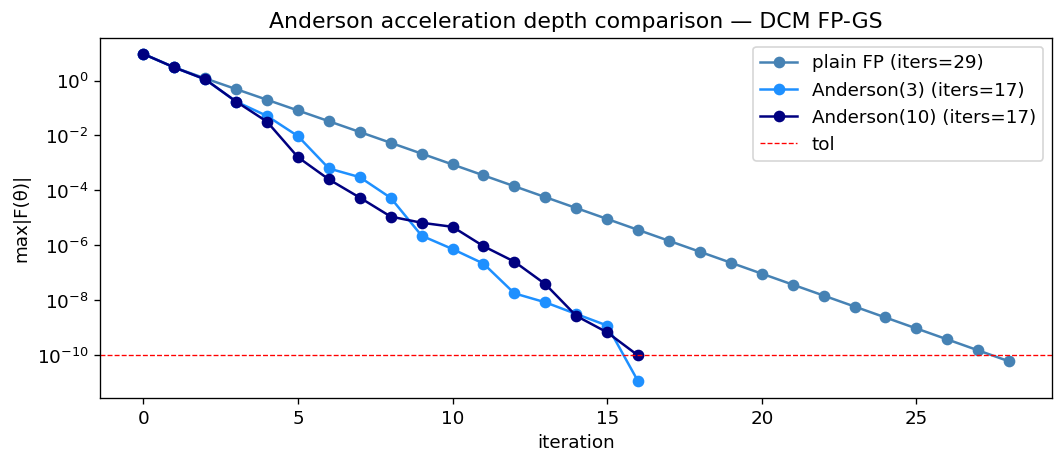

In [28]:
# Compare plain FP vs Anderson(1) vs Anderson(10) on DCM
fig, ax = plt.subplots(figsize=(9, 4))

colors = ['steelblue','dodgerblue', 'navy']
labels_depths = [('plain FP', 0), ('Anderson(3)', 3), ('Anderson(10)', 10)]

for (label, depth), color in zip(labels_depths, colors):
    r = solve_fixed_point_dcm(
        model.residual, theta0, model.k_out, model.k_in,
        tol=1e-10, max_iter=500,
        variant='gauss-seidel', anderson_depth=depth,
    )
    ax.semilogy(r.residuals, label=f'{label} (iters={r.iterations})', color=color, marker='o')

ax.axhline(1e-10, color='red', linestyle='--', linewidth=0.8, label='tol')
ax.set_xlabel('iteration'); ax.set_ylabel('max|F(θ)|')
ax.set_title('Anderson acceleration depth comparison — DCM FP-GS')
ax.legend()
plt.tight_layout()
plt.show()

---
## 6. Parametrisation and Initial Conditions

### 6.1 Why θ-space?

All multipliers are stored as $\theta_i = -\log(x_i) > 0$.  This ensures:
- $x_i = e^{-\theta_i} > 0$ without box constraints
- $z_{ij} = \theta^{\text{out}}_i + \theta^{\text{in}}_j > 0$ (feasibility for DWCM/DaECM) can be enforced as a simple linear inequality
- The likelihood surface is smoother and better conditioned in $\theta$-space

### 6.2 Initial conditions matter

Good initial conditions reduce iteration counts significantly.  The models provide several options:

In [29]:
# DCM initial conditions
theta_degrees = model.initial_theta('degrees')  # θ_i = -log(k_i / (N-1))
theta_random  = model.initial_theta('random')   # uniform in [0.5, 2.5]

print('DCM initial conditions (first 5 values):')
print(f'  degrees:  {theta_degrees[:5].numpy().round(3)}')
print(f'  random:   {theta_random[:5].numpy().round(3)}')

DCM initial conditions (first 5 values):
  degrees:  [1.599 0.795 1.599 0.973 1.141]
  random:   [1.035 1.581 0.535 0.808 0.852]


In [30]:
# DWCM initial conditions
theta_str = model_w.initial_theta('strengths')  # θ_i = -log(s_i / (N-1))
theta_norm = model_w.initial_theta('normalized') # normalised version
print('DWCM initial conditions (first 5 values):')
print(f'  strengths:  {theta_str[:5].numpy().round(3)}')
print(f'  normalized: {theta_norm[:5].numpy().round(3)}')

DWCM initial conditions (first 5 values):
  strengths:  [1.19  0.602 1.292 0.725 0.887]
  normalized: [4.801 3.366 5.024 3.702 4.108]


In [31]:
# DaECM weight initial conditions
# 'balanced': θ_i = -log(global_mean_weight / (global_mean_weight + 1))
# 'topology': θ_i = 0.5 * log((k_i + 1) / (s_i - k_i + 1))
theta_bal = model_da.initial_theta_weight(theta_topo, method='balanced')
theta_top = model_da.initial_theta_weight(theta_topo, method='topology')
print('DaECM weight initial conditions (first 5 out-values):')
print(f'  balanced:  {theta_bal[:5].numpy().round(3)}')
print(f'  topology:  {theta_top[:5].numpy().round(3)}')

DaECM weight initial conditions (first 5 out-values):
  balanced:  [0.285 0.285 0.285 0.285 0.285]
  topology:  [0.255 0.323 0.347 0.314 0.347]


---
## 7. Working with Large Networks

### 7.1 The chunked computation path

For N > 2000, constructing the full N×N probability matrix requires O(N²) RAM (200 MB at N=5000, 20 GB at N=50000).  All solvers in this package automatically switch to a **chunked path** for N > `_LARGE_N_THRESHOLD = 2000`:

- The N×N matrix is never fully materialised
- Instead, rows are processed in blocks of `chunk_size = 512`
- Peak RAM per iteration: O(chunk × N) = O(512 × N) ≈ 20 MB at N=5000
- Same numerical result; slightly higher overhead per iteration

In [32]:
# Medium-scale example: N=500 (dense path)
N_large = 500
k_large, _ = k_s_generator_pl(N_large, rho=1e-2, seed=7)
k_out_l = k_large[:N_large].numpy().astype(float)
k_in_l  = k_large[N_large:].numpy().astype(float)

model_l = DCMModel(k_out_l, k_in_l)
theta0_l = model_l.initial_theta('degrees')

r_l = solve_fixed_point_dcm(
    model_l.residual, theta0_l, model_l.k_out, model_l.k_in,
    tol=1e-6, max_iter=2000,
    variant='theta-newton', anderson_depth=10,
)
print(f'N={N_large}:  converged={r_l.converged}  iters={r_l.iterations}')
print(f'  max_err = {model_l.constraint_error(r_l.theta):.2e}')
print(f'  time (s) = {r_l.elapsed_time:.3f}')
print(f'  peak RAM = {r_l.peak_ram_bytes / 1e6:.1f} MB')

N=500:  converged=True  iters=13
  max_err = 9.96e-07
  time (s) = 0.113
  peak RAM = 0.0 MB


### 7.2 Robustness features

All three solvers include several robustness features:

| Feature | Purpose |
|---------|---------|
| **θ clamping** (`θ ∈ [-50, 50]`) | Prevents numerical overflow in `exp(-θ)` |
| **z-floor guard** (DWCM/DaECM) | Ensures `θ_out + θ_in > 1e-8` for all pairs |
| **Anderson blowup reset** | When residual jumps >5000×, clears history and reverts to `best_theta` |
| **Anderson infeasibility reject** | If Anderson mix violates z-floor, rejects and uses plain Newton step |
| **best_theta tracking** | Returns lowest-residual iterate, not final iterate |
| **Node-level Newton fallback** (FP-GS) | When `|Δθ_FP| > 0.1`, uses exact diagonal Newton step for that node |

### 7.3 Timeout and multi-init

The `max_time` parameter (in seconds) is honoured at the iteration level.  For the comparison benchmarks, a multi-initialisation wrapper tries multiple starting points and returns the best converged result:

In [33]:
# max_time example
r_timed = solve_fixed_point_dcm(
    model.residual, theta0, model.k_out, model.k_in,
    tol=1e-12, max_iter=100_000,
    variant='theta-newton', anderson_depth=10,
    max_time=0.5,  # stop after 0.5 seconds
)
print(f'Timed run: converged={r_timed.converged}  iters={r_timed.iterations}')
print(f'  max_err={model.constraint_error(r_timed.theta):.2e}  time={r_timed.elapsed_time:.3f}s')

Timed run: converged=True  iters=18
  max_err=2.54e-13  time=0.032s


---
## 8. Interpreting the SolverResult

Every solver returns a `SolverResult` dataclass:

In [34]:
from src.solvers.base import SolverResult

r = result_tn
print(repr(r))
print()
print(f'Fields:')
print(f'  theta          : np.ndarray shape ({len(r.theta)},) — solution in θ-space')
print(f'  converged      : {r.converged}          — True if tol reached')
print(f'  iterations     : {r.iterations}             — number of outer iterations')
print(f'  residuals      : list of {len(r.residuals)} floats — ℓ∞ residual history')
print(f'  elapsed_time   : {r.elapsed_time:.4f}       — wall-clock seconds')
print(f'  peak_ram_bytes : {r.peak_ram_bytes}     — tracemalloc peak')
print(f'  message        : "{r.message}"')

# Convenience properties
print()
print(f'result.x[:5] = {r.x[:5].round(3)}   (exp(-θ_out))')
print(f'result.y[:5] = {r.y[:5].round(3)}   (exp(-θ_in))')

SolverResult(CONVERGED, iters=13, final_residual=8.845e-09, time=0.029s, peak_ram=8.2 KB)

Fields:
  theta          : np.ndarray shape (100,) — solution in θ-space
  converged      : True          — True if tol reached
  iterations     : 13             — number of outer iterations
  residuals      : list of 13 floats — ℓ∞ residual history
  elapsed_time   : 0.0286       — wall-clock seconds
  peak_ram_bytes : 8381     — tracemalloc peak
  message        : "Converged in 13 iteration(s)."

result.x[:5] = [0.123 0.775 0.118 0.495 0.325]   (exp(-θ_out))
result.y[:5] = [1.21  0.586 0.397 0.772 0.402]   (exp(-θ_in))


---
## 9. Quick Reference

```python
# DCM
from src.models.dcm import DCMModel
from src.solvers.fixed_point_dcm import solve_fixed_point_dcm

model = DCMModel(k_out, k_in)
theta0 = model.initial_theta('degrees')
result = solve_fixed_point_dcm(
    model.residual, theta0, model.k_out, model.k_in,
    tol=1e-6, variant='theta-newton', anderson_depth=10,
)

# DWCM
from src.models.dwcm import DWCMModel
from src.solvers.fixed_point_dwcm import solve_fixed_point_dwcm

model = DWCMModel(s_out, s_in)
theta0 = model.initial_theta('strengths')
result = solve_fixed_point_dwcm(
    model.residual, theta0, model.s_out, model.s_in,
    tol=1e-6, variant='theta-newton', anderson_depth=10,
)

# DaECM (two-step)
from src.models.daecm import DaECMModel
from src.solvers.fixed_point_daecm import solve_fixed_point_daecm

model = DaECMModel(k_out, k_in, s_out, s_in)

dcm = DCMModel(model.k_out, model.k_in)

# Step 1: topology
sr_topo = solve_fixed_point_dcm(
    dcm.residual, model.initial_theta_topo(),
    model.k_out, model.k_in,
    tol=1e-6, variant='theta-newton', anderson_depth=10,
)
theta_topo = sr_topo.theta

# Step 2: weights
import functools
res_w = functools.partial(model.residual_strength, theta_topo=theta_topo)
sr_weight = solve_fixed_point_daecm(
    res_w, model.initial_theta_weight(theta_topo),
    model.s_out, model.s_in,
    theta_topo=theta_topo, P=None,
    tol=1e-5, variant='theta-newton', anderson_depth=10,
)
```

### Choosing the right solver

| Situation | Recommended solver |
|-----------|--------------------|
| DCM, any size | Either; both 100% convergent |
| DWCM, N ≤ 5000, typical network | FP-GS Anderson(10) (faster) |
| DWCM, N ≤ 5000, hard network (high s/k) | θ-Newton Anderson(10) (more robust) |
| DWCM, N > 5000 | θ-Newton Anderson(10) |
| DaECM, any size | θ-Newton Anderson(10) (**only reliable method at N ≥ 5000**) |

---
## 10. References

1. Park, J. & Newman, M.E.J. (2004). Statistical mechanics of networks. *Physical Review E*, **70**, 066117.

2. Squartini, T. & Garlaschelli, D. (2011). Analytical maximum-likelihood method to detect patterns in real networks. *New Journal of Physics*, 13, 083001. https://doi.org/10.1088/1367-2630/13/8/083001

3. Mastrandrea, R., Squartini, T., Fagiolo G., and Garlaschelli, D. (2014). Enhanced reconstruction of weighted networks from strengths and degrees. *New Journal of Physics*, 16 043022
https://iopscience.iop.org/article/10.1088/1367-2630/16/4/043022

4. Gabrielli, A, Mastrandrea, R., Caldarelli, G. and Cimini, G. (2019) Grand canonical ensemble of weighted networks. *Phys. Rev. E* 99, 030301(R) 
https://journals.aps.org/pre/abstract/10.1103/PhysRevE.99.030301

5. Parisi, F., Squartini, T. and Garlaschelli, D. (2020). A faster horse on a safer trail: generalized inference for the efficient reconstruction of weighted networks. *New Journal of Physics*, 22 053053
https://iopscience.iop.org/article/10.1088/1367-2630/ab74a7

6. Walker, H.F. & Ni, P. (2011). Anderson acceleration for fixed-point iterations. *SIAM Journal on Numerical Analysis*, **49**(4), 1715–1735.